In [1]:
import sys
import os

# 1. Fix module imports
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 2. Fix file paths by changing the working directory
# We check if we are currently in the 'notebooks' folder to avoid stepping back too far if you run this cell twice.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir('..')
    
print(f"System path includes: {parent_dir}")
print(f"Current working directory is: {os.getcwd()}")

from src import (
    load_raw,
    get_prices_returns_volume,
    get_returns_long,
    get_volume_long,
    get_metadata,
    process_universe_etfs,
    load_prices_etf,
    download_prices_etf,
    get_returns_etf,
    get_returns_long_etf,
    compute_sector_correlation_matrix,
    compute_correlation_distribution,
    run_full_strategy,
    run_full_strategy_pca,
    plot_correlation_heatmap,
    plot_correlation_histogram,
    plot_performance, 
    run_pca_parameter_sweep
)

System path includes: /Users/saurabhgupta/Desktop/Courses, Projects and Internships/Algorithmic trading/Statistical arbitrage in US equity markets using PCA
Current working directory is: /Users/saurabhgupta/Desktop/Courses, Projects and Internships/Algorithmic trading/Statistical arbitrage in US equity markets using PCA


In [2]:
# ------------------------------------------------------------------------------
# 1. DATA INGESTION & PIPELINE
# ------------------------------------------------------------------------------
# Load local raw data (respecting the offline requirement)
raw = load_raw()
prices, returns, volume = get_prices_returns_volume(raw)

returns_long = get_returns_long(returns)
volume_long = get_volume_long(volume)

# Build the long-format panel
panel = returns_long.merge(volume_long, on=["date", "ticker"], how="left")

# ------------------------------------------------------------------------------
# 2. METADATA & ETF MAPPING
# ------------------------------------------------------------------------------
# get_metadata evaluates the local returns matrix and merges it with the local universe_metadata.csv
metadata_raw = get_metadata(returns)

# Execute ETF mapping
metadata, etfs, t2e, e2t = process_universe_etfs()

# Try to load local ETF data first. Only download if it doesn't exist.
try:
    prices_etf = load_prices_etf()
except FileNotFoundError:
    print("Local ETF prices not found. Falling back to yfinance download...")
    prices_etf = download_prices_etf(etfs)

returns_etf = get_returns_etf(prices_etf)
returns_long_etf = get_returns_long_etf(returns_etf)



Loading local data from data/raw/raw_data.csv...
Original data shape: (1258, 500)
Raw data loading complete.
Returns calculated. Shape: (1257, 100)
Price data saved to data/raw/prices.csv
Returns data saved to data/raw/returns.csv
Volume data saved to data/raw/volume.csv
Returns data saved to data/raw/returns_long.csv in long-format
Volume data saved to data/raw/volume_long.csv in long-format
Local metadata found. Updating statistical metrics without network calls.
Metadata saved to data/raw/universe_metadata.csv
Loading metadata from data/raw/universe_metadata.csv...
Successfully added 'etf' column and updated data/raw/universe_metadata.csv
Identified 11 unique sector ETFs: ['XLK', 'XLY', 'XLC', 'XLU', 'XLF', 'XLV', 'XLP', 'XLI', 'XLB', 'XLRE', 'XLE']
Loading local data from data/raw/prices_etf.csv...
Original data shape: (1258, 11)
Raw ETF data loading complete.
Returns calculated. Shape: (1257, 11)
ETF returns data saved to data/raw/returns_etf.csv
ETF returns data saved to data/raw

Filtering universe for full coverage and sorting by sector...
Kept 98 highly liquid, full-coverage stocks.
Generating heatmap...
Heatmap saved to data/results/correlation_heatmap.png


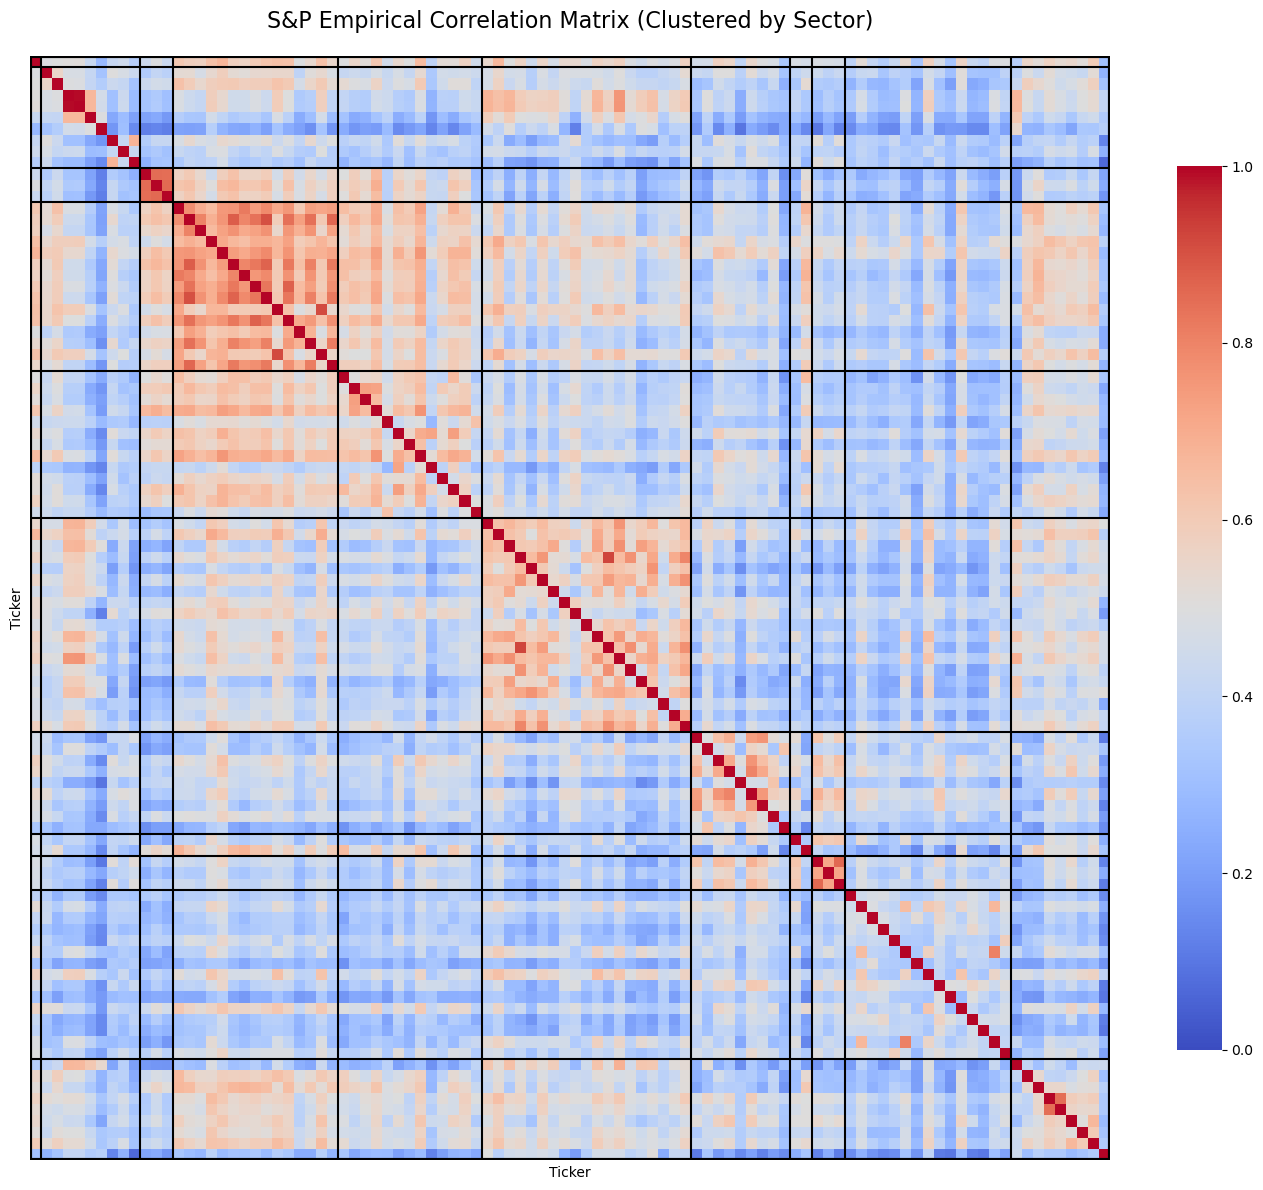

Generating distribution histogram...
Histogram saved to data/results/correlation_histogram.png


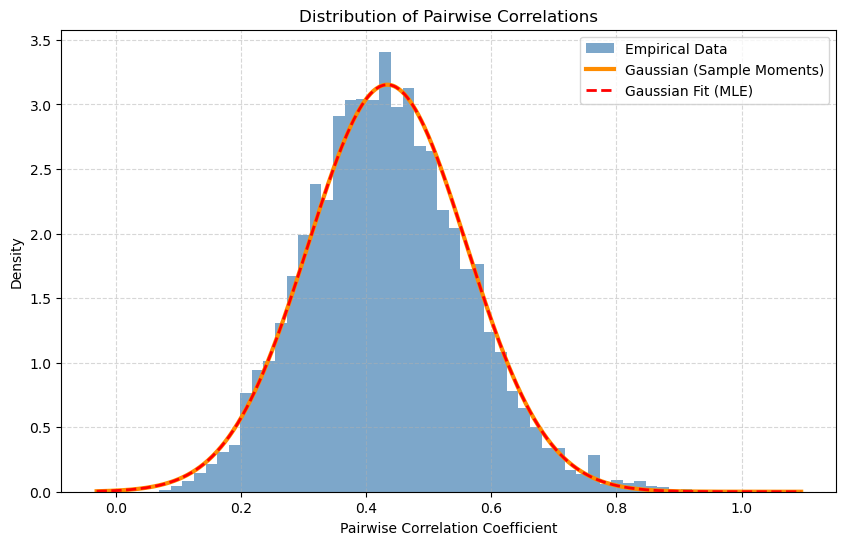

In [3]:
# ------------------------------------------------------------------------------
# 3. MATHEMATICAL ANALYSIS & VISUALIZATION
# ------------------------------------------------------------------------------
# Compute Correlation Matrix and Boundaries
corr_matrix, ordered_tickers, boundaries = compute_sector_correlation_matrix(returns, metadata)

# Plot Heatmap
plot_correlation_heatmap(
    corr_matrix, 
    ordered_tickers, 
    boundaries, 
    save_path="data/results/correlation_heatmap.png"
)

# Compute Distribution Moments and Gaussian Fit
corr_dist, stats_dict = compute_correlation_distribution(corr_matrix)

# Plot Histogram
plot_correlation_histogram(
    corr_dist, 
    stats_dict, 
    save_path="data/results/correlation_histogram.png"
)



Starting rolling backtest simulation (Train: 252, Test: 21)...
Simulation Complete.
Performance plot saved to data/results/etf_performance.png


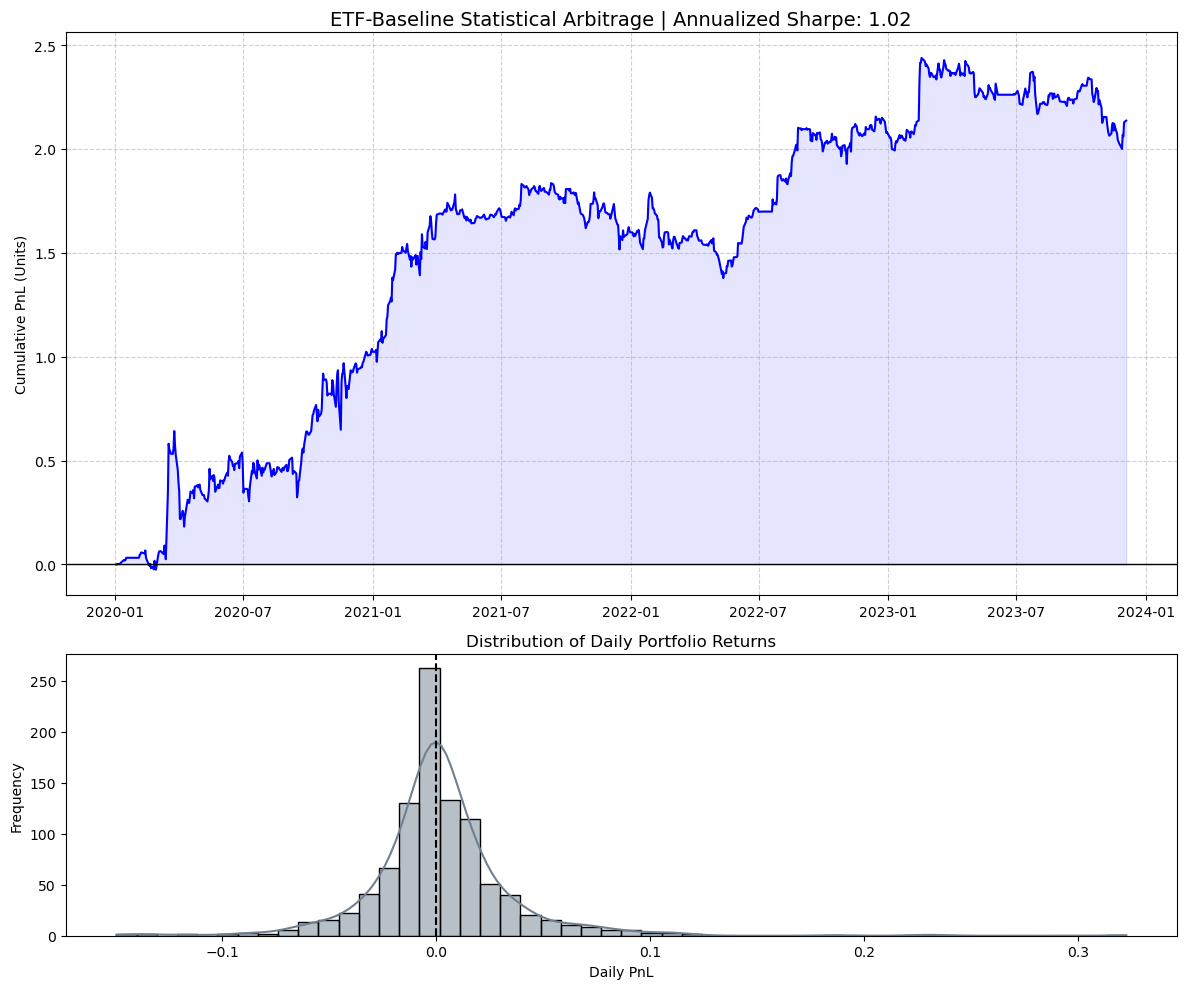

Starting rolling PCA backtest simulation (10 Factors)...
Simulation Complete.
Performance plot saved to data/results/pca_performance.png


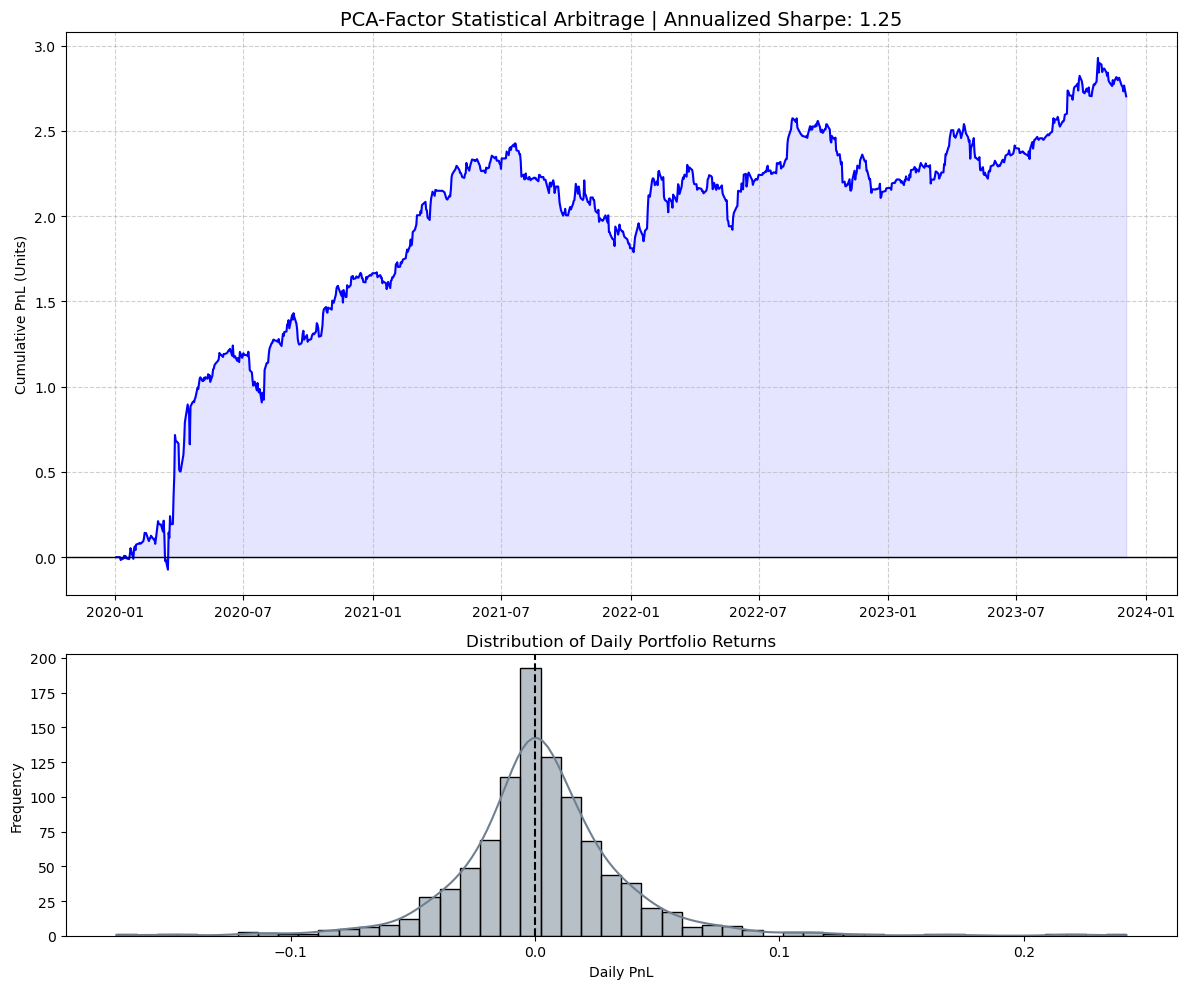

In [7]:
# ------------------------------------------------------------------------------
# 4. STRATEGY SIMULATIONS
# ------------------------------------------------------------------------------

# Baseline: ETF Sector Regression Statistical Arbitrage
strategy_daily_returns = run_full_strategy(
    returns, 
    returns_etf, 
    volume, 
    t2e, 
    
    # --- Tunable Parameters ---
    train_days=252,          # Lookback window for OU calibration
    test_days=21,            # Out-of-sample trading window before recalibrating
    entry_threshold=1.50,    # Z-score required to open a pair trade
    exit_threshold=0.75,     # Z-score target to flatten the position
    adf_p_threshold=0.05,    # Stricter values (e.g., 0.01) enforce higher mean-reversion certainty
    avg_window=60            # Moving average days for the volume dampener
)

plot_performance(
    strategy_daily_returns, 
    model_name="ETF-Baseline", 
    save_path="data/results/etf_performance.png"
)


# Advanced: PCA Multi-Factor Statistical Arbitrage
strategy_daily_returns_pca = run_full_strategy_pca(
    returns, 
    returns_etf, 
    volume, 
    t2e, 
    
    # --- Tunable Parameters ---
    train_days=252,          # Lookback window for PCA and OU calibration
    test_days=21,            # Out-of-sample trading window before recalibrating
    num_factors=10,          # Number of principal components to hedge against (e.g., 3, 5, 15)
    entry_threshold=1.5,     # Z-score required to open a pair trade
    exit_threshold=0.75,     # Z-score target to flatten the position
    adf_p_threshold=0.05,    # Stricter values (e.g., 0.01) enforce higher mean-reversion certainty
    avg_window=60            # Moving average days for the volume dampener
)

plot_performance(
    strategy_daily_returns_pca, 
    model_name="PCA-Factor", 
    save_path="data/results/pca_performance.png"
)

Initializing Hyperparameter Grid Search...
Total parameter combinations to test: 32

--- Run 1/32 | Testing: {'train_days': 252, 'test_days': 21, 'avg_window': 60, 'adf_p_threshold': 0.025, 'num_factors': 3, 'entry_threshold': 1.25, 'exit_threshold': 0.5} ---
Starting rolling PCA backtest simulation (3 Factors)...
Simulation Complete.
Result -> Sharpe: -0.2210 | Total Ret: -0.4830

--- Run 2/32 | Testing: {'train_days': 252, 'test_days': 21, 'avg_window': 60, 'adf_p_threshold': 0.025, 'num_factors': 3, 'entry_threshold': 1.25, 'exit_threshold': 0.75} ---
Starting rolling PCA backtest simulation (3 Factors)...
Simulation Complete.
Result -> Sharpe: -0.1281 | Total Ret: -0.2754

--- Run 3/32 | Testing: {'train_days': 252, 'test_days': 21, 'avg_window': 60, 'adf_p_threshold': 0.025, 'num_factors': 3, 'entry_threshold': 1.5, 'exit_threshold': 0.5} ---
Starting rolling PCA backtest simulation (3 Factors)...
Simulation Complete.
Result -> Sharpe: -0.2607 | Total Ret: -0.5491

--- Run 4/32 | 

/Users/saurabhgupta/Desktop/Courses, Projects and Internships/Algorithmic trading/Statistical arbitrage in US equity markets using PCA/src/optimization.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


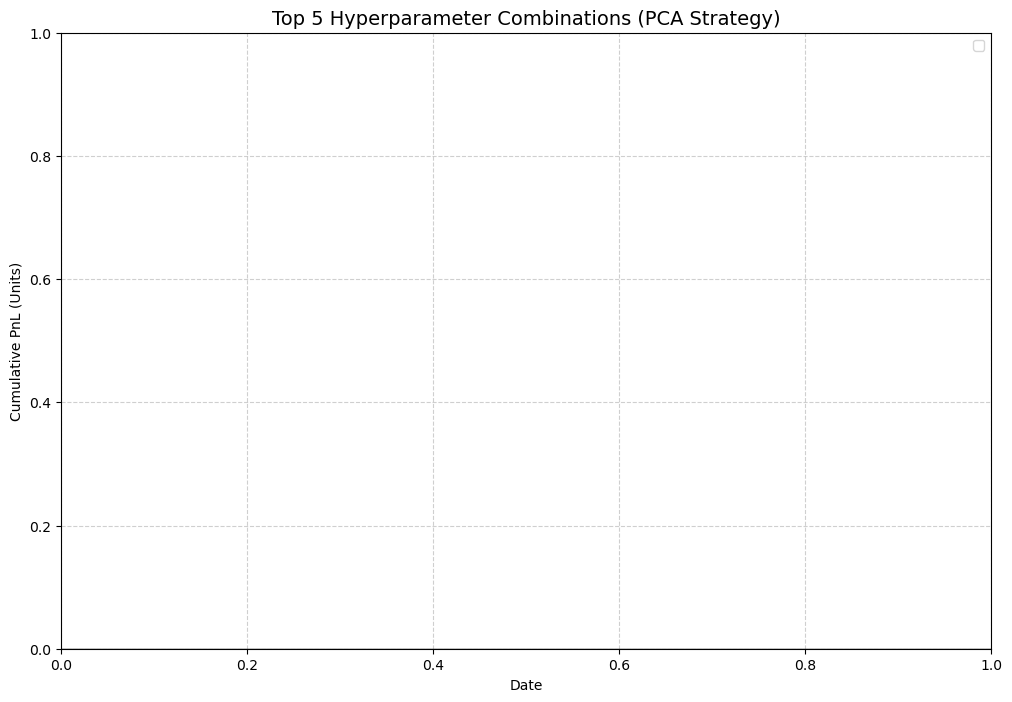


--- OPTIMAL PCA PARAMETERS FOUND ---
train_days: 252.0
test_days: 21.0
avg_window: 60.0
adf_p_threshold: 0.05
num_factors: 10.0
entry_threshold: 1.5
exit_threshold: 0.75
sharpe: 1.247620808842787
total_return: 2.7028496145609076


In [5]:
# Define the grid of parameters you want to test.
# Warning: The number of total runs is the product of the lengths of these lists.
# Keep lists short to avoid excessive computation time!

pca_param_grid = {
    # Structural Params (Usually frozen to save time)
    'train_days': [252],       
    'test_days': [21],         
    'avg_window': [60],        
    'adf_p_threshold': [0.05], 
    
    # Signal Generation Params (The variables to sweep)
    'num_factors': [5, 8, 10, 12],     # Testing 3 different factor exposures
    'entry_threshold': [1.25, 1.50],      # Testing standard vs stricter entry
    'exit_threshold': [0.50, 0.75]        # Testing early exit vs returning completely to mean
}

# Run the grid search
# This will execute 3 * 2 * 2 = 12 full backtests.
results_df, curves = run_pca_parameter_sweep(
    returns_wide=returns, 
    etf_returns=returns_etf, 
    volume_wide=volume, 
    t2e_dict=t2e, 
    param_grid=pca_param_grid,
    save_path="data/results/pca_grid_search.png"
)

# Extract the absolute best parameters from the top row of the results dataframe
best_params = results_df.iloc[0].to_dict()
print("\n--- OPTIMAL PCA PARAMETERS FOUND ---")
for k, v in best_params.items():
    print(f"{k}: {v}")